# SCLC / LUAD / normal T-cell fine-tuning and perturbation

## TL;DR

Fine-tuning and held-out classification are **complete**: 0.919 accuracy,
0.903 macro F1 on the donor-held-out HTAN test set, notably higher than the
prior LUAD/LUSC/normal model (0.783 / 0.758). The donor-aware, all-gene
deletion + overexpression in-silico perturbation screen is **designed and
launched, currently paused** pending a runtime/scope decision (the full
752-shard sweep -- both perturbation types across all three sources --
projects to roughly 7-8 days on the available GPU; batch-size tuning only
bought a modest gain since the workload is compute-bound, not
batch-limited).

## Context and methods

This is the SCLC-inclusive counterpart to the repository's LUAD/LUSC/normal
T-cell classifier and all-gene perturbation screen, built on the HTAN
T-cell cohort identified by `sclc_validation/audit/`. Full methodology,
including the donor-disjoint-across-disease guard for three patients who
each contribute both LUAD tumor and normal-tissue T cells, is in
`../METHODS.md`. This notebook reads the machine-generated result tables in
`../results/`.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

WORKFLOW_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd() / "sclc_validation/perturbation_workflow"
RESULTS = WORKFLOW_DIR / "results"

test_metrics = json.loads((RESULTS / "test_metrics.json").read_text())
classification_report = json.loads((RESULTS / "classification_metrics_report.json").read_text())
confusion = pd.read_csv(RESULTS / "test_confusion_matrix.csv", index_col=0)
donor_split = pd.read_csv(RESULTS / "htan_donor_split_assignment.csv")
cohort_summary = pd.read_csv(RESULTS / "htan_cohort_characterization_summary.csv")
cohort_summary

,disease,split,n_cells,n_donors
0,lung adenocarcinoma,eval,5611,4
1,lung adenocarcinoma,test,6387,4
2,lung adenocarcinoma,train,17831,14
3,normal,eval,1620,1
4,normal,test,566,1
5,normal,train,2334,2
6,small cell lung carcinoma,eval,2330,3
7,small cell lung carcinoma,test,2424,3
8,small cell lung carcinoma,train,7037,13


## Cohort and split

HTAN/CELLxGENE T-cell object only (46,140 T cells, 42 donors) -- no other
dataset is blended in. The normal class is thin by design (4 donors total,
2 train / 1 eval / 1 test); this is a named limitation, not silently treated
as equivalent in power to the SCLC/LUAD arms.

In [2]:
assert test_metrics["donor_leakage_check"] == "PASS"
cross_disease_donors = (
    donor_split.groupby("individual")["disease"].nunique()
)
assert (cross_disease_donors > 1).sum() == 3, "Expected 3 cross-disease (paired tumor/normal) donors"
print("Donor-leakage check (including cross-disease guard): PASS")
print("Cross-disease donors:", cross_disease_donors[cross_disease_donors > 1].index.tolist())

Donor-leakage check (including cross-disease guard): PASS
Cross-disease donors: ['RU675', 'RU682', 'RU684']


## Classification results

In [3]:
print(f'Held-out accuracy: {classification_report["overall_accuracy"]:.3f}')
print(f'Held-out macro F1:  {classification_report["overall_macro_f1"]:.3f}')
print()
print("Prior LUAD/LUSC/normal model (calibration reference, different classes/cohort):")
prior = classification_report["prior_workflow_context"]
print(f'  accuracy {prior["held_out_accuracy"]:.3f}, macro F1 {prior["held_out_macro_f1"]:.3f}')
pd.DataFrame(classification_report["per_class"]).sort_values("disease")

Held-out accuracy: 0.919
Held-out macro F1:  0.903

Prior LUAD/LUSC/normal model (calibration reference, different classes/cohort):
  accuracy 0.783, macro F1 0.758


,disease,precision,recall,f1,n_test_cells,n_test_donors
0,lung adenocarcinoma,0.925612,0.958660,0.941846,6386,4
1,normal,0.846737,0.985866,0.911020,566,1
2,small cell lung carcinoma,0.922492,0.800330,0.857080,2424,3


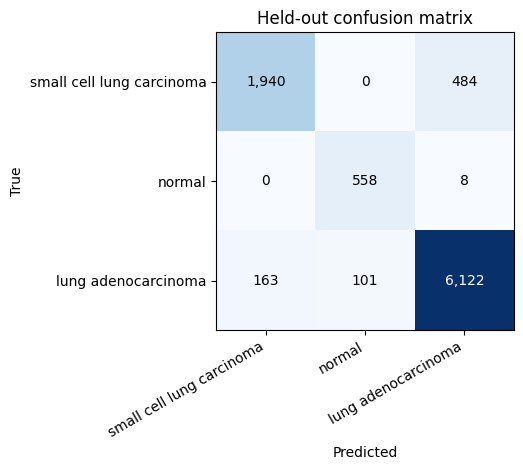

In [4]:
fig, ax = plt.subplots(figsize=(5.5, 4.8))
im = ax.imshow(confusion.values, cmap="Blues")
ax.set_xticks(range(len(confusion.columns)), confusion.columns, rotation=30, ha="right")
ax.set_yticks(range(len(confusion.index)), confusion.index)
for i in range(confusion.shape[0]):
    for j in range(confusion.shape[1]):
        ax.text(j, i, f"{confusion.values[i, j]:,}", ha="center", va="center",
                color="white" if confusion.values[i, j] > confusion.values.max() / 2 else "black")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Held-out confusion matrix")
plt.tight_layout()
plt.show()

SCLC's main confusion is with LUAD (~20% of SCLC test cells called LUAD,
almost none with normal) -- the biologically closer pair of the two tumor
types. Normal's near-perfect recall is a single-donor result and should be
read as one data point, not a population estimate.

## In-silico perturbation -- design and status

Every gene token in every held-out test cell is perturbed individually,
once per type (**delete**: removed from the rank-value encoding;
**overexpress**: moved to the front, simulating maximal relative
expression), and scored against training-cells-only disease reference
embeddings. Three source screens (SCLC, LUAD, normal) recover all six
directional comparisons per type. A gene whose deletion and overexpression
move a cell in opposite directions is the strongest evidence tier.

An earlier plan to restrict this screen to the top 3000 variable genes was
reverted: Geneformer's `InSilicoPerturber` has no built-in "sweep
individually, restricted to a list" mode -- passing a gene list perturbs the
whole list as one combined event, not one gene at a time. Running all genes
avoids a reduced-context-embedding deviation from the prior workflow's
methodology, at the cost of a substantially larger compute budget.

**Status at notebook build time**: the sweep is designed, launched, and
currently paused after a throughput-tuning experiment (forward_batch_size
128 vs. 16 only reduced per-shard time from ~15 min to ~12.9 min -- the
workload is GPU-compute-bound, not batch-limited). The full 752-shard sweep
(2 perturbation types x 3 sources) projects to roughly 7-8 days; results will
be added to `../RESULTS.md` once a runtime/scope decision is made and the
sweep completes.

## Takeaways so far

1. The SCLC/LUAD/normal classifier clears a materially higher held-out bar
   (0.919 accuracy / 0.903 macro F1) than the prior LUAD/LUSC/normal model,
   though the two are not a head-to-head comparison (different classes,
   different cohort).
2. SCLC-vs-LUAD is the classifier's main source of confusion; SCLC-vs-normal
   is essentially clean.
3. The normal class's single test donor means its metrics should be treated
   as a single-patient data point, not validated population performance.
4. The perturbation screen's full scope (all genes, both delete and
   overexpress) is real compute, not a quick follow-up -- a scope or
   runtime decision is needed before it can complete.